In [6]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('/content/faults.csv')

# Display the first few rows of the DataFrame
print(df.head())

   X_Minimum  X_Maximum  Y_Minimum  Y_Maximum  Pixels_Areas  X_Perimeter  \
0         42         50     270900     270944           267           17   
1        645        651    2538079    2538108           108           10   
2        829        835    1553913    1553931            71            8   
3        853        860     369370     369415           176           13   
4       1289       1306     498078     498335          2409           60   

   Y_Perimeter  Sum_of_Luminosity  Minimum_of_Luminosity  \
0           44              24220                     76   
1           30              11397                     84   
2           19               7972                     99   
3           45              18996                     99   
4          260             246930                     37   

   Maximum_of_Luminosity  ...  Orientation_Index  Luminosity_Index  \
0                    108  ...             0.8182           -0.2913   
1                    123  ...             

### Data Preprocessing: Defining Target and Splitting Data

We will now define our target variable and prepare the dataset for model training. The goal is to predict `Z_Scratch`.

In [14]:
from sklearn.model_selection import train_test_split

# Define the target variable
y = df['Z_Scratch']

# Define columns to drop:
# 1. Other potential targets
# 2. Redundant features identified via correlation (X_Maximum and Y_Maximum)
target_columns_to_drop = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
redundant_features = ['X_Maximum', 'Y_Maximum']

all_to_drop = target_columns_to_drop + redundant_features

# Filter out only the columns that actually exist in the DataFrame
drop_existing = [col for col in all_to_drop if col in df.columns]

# Define features (X) by dropping the target and redundant columns
X = df.drop(columns=drop_existing)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"New features count: {X.shape[1]}")
print(f"Dropped columns: {drop_existing}")
print(f"Shape of X_train: {X_train.shape}")

New features count: 25
Dropped columns: ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults', 'X_Maximum', 'Y_Maximum']
Shape of X_train: (1552, 25)


### Outlier Detection and Removal

We will use the Isolation Forest algorithm to detect and remove outliers from our training data. This can help improve the robustness and generalization of our models by mitigating the impact of anomalous data points.

In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure data is split before outlier detection
y = df['Z_Scratch']
target_columns_to_drop = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
target_columns_to_drop_existing = [col for col in target_columns_to_drop if col in df.columns]
X = df.drop(columns=target_columns_to_drop_existing)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Isolation Forest model
iso_forest = IsolationForest(random_state=42, contamination=0.05)

# Fit on X_train and predict outliers
outlier_preds_train = iso_forest.fit_predict(X_train)

# Filter out outliers from X_train and y_train
X_train_cleaned = X_train[outlier_preds_train == 1]
y_train_cleaned = y_train[outlier_preds_train == 1]

# Predict outliers in the test set
outlier_preds_test = iso_forest.predict(X_test)

# Filter out outliers from X_test and y_test
X_test_cleaned = X_test[outlier_preds_test == 1]
y_test_cleaned = y_test[outlier_preds_test == 1]

print(f"Original X_train shape: {X_train.shape}")
print(f"Cleaned X_train shape: {X_train_cleaned.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Cleaned y_train shape: {y_train_cleaned.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Cleaned X_test shape: {X_test_cleaned.shape}")

Original X_train shape: (1552, 27)
Cleaned X_train shape: (1474, 27)
Original y_train shape: (1552,)
Cleaned y_train shape: (1474,)
Original X_test shape: (389, 27)
Cleaned X_test shape: (368, 27)


### Data Quality Check: Null Values and Data Types

Before proceeding, it's important to understand the completeness of our data and the data types of each feature. This helps in identifying potential issues like missing values or incorrect data types that might affect model performance.

In [9]:
# Check for null values in the DataFrame
null_counts = df.isnull().sum()
print("Null values in each column:")
print(null_counts[null_counts > 0])

# Display data types of each column
print("\nData types of each column:")
print(df.info())

Null values in each column:
Series([], dtype: int64)

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941

### Feature Correlation Analysis

We will now calculate and visualize the correlation between our features to understand their relationships.

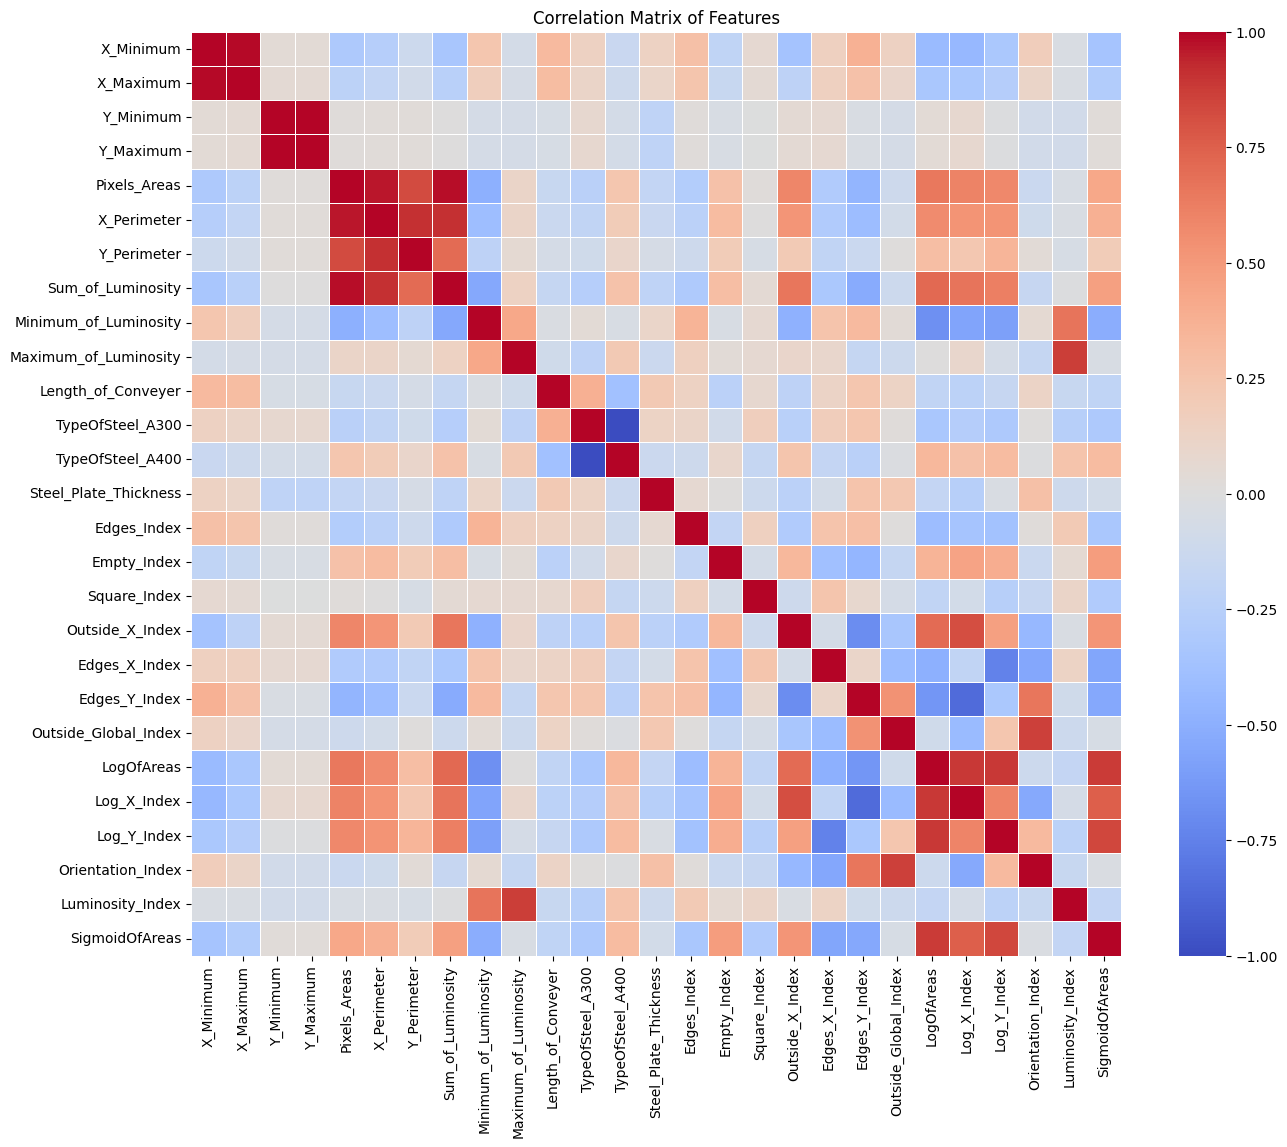

Top Correlations:


,,0
Y_Minimum,Y_Maximum,1.000000
X_Maximum,X_Minimum,0.988314
Pixels_Areas,Sum_of_Luminosity,0.978952
X_Perimeter,Pixels_Areas,0.966644
Sum_of_Luminosity,X_Perimeter,0.912956
Y_Perimeter,X_Perimeter,0.912436
LogOfAreas,Log_X_Index,0.888919
Log_Y_Index,LogOfAreas,0.882974
SigmoidOfAreas,LogOfAreas,0.877768
Maximum_of_Luminosity,Luminosity_Index,0.870160


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the features in X
corr_matrix = X.corr()

# Set up the matplotlib figure
plt.figure(figsize=(15, 12))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Features')
plt.show()

# Display the top correlations
print("Top Correlations:")
# Unstack the correlation matrix and filter for unique pairs
sorted_corr = corr_matrix.unstack().sort_values(ascending=False)
sorted_corr = sorted_corr[sorted_corr < 1].drop_duplicates()
display(sorted_corr.head(10))

### Model Training and Evaluation

Now, let's train and evaluate our chosen models: XGBoost, LightGBM, and Random Forest. We will assess their performance using classification reports on both the training and testing datasets.

#### 1. XGBoost Classifier

In [10]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Initialize and train the XGBoost Classifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred_xgb = xgb_model.predict(X_train)
print("XGBoost - Training Classification Report:")
print(classification_report(y_train, y_train_pred_xgb))

# Make predictions on the test set
y_test_pred_xgb = xgb_model.predict(X_test)
print("\nXGBoost - Test Classification Report:")
print(classification_report(y_test, y_test_pred_xgb))

XGBoost - Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1403
           1       1.00      1.00      1.00       149

    accuracy                           1.00      1552
   macro avg       1.00      1.00      1.00      1552
weighted avg       1.00      1.00      1.00      1552


XGBoost - Test Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       348
           1       1.00      0.90      0.95        41

    accuracy                           0.99       389
   macro avg       0.99      0.95      0.97       389
weighted avg       0.99      0.99      0.99       389



#### 2. LightGBM Classifier

In [11]:
import lightgbm as lgb
from sklearn.metrics import classification_report

# Initialize and train the LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42)
lgbm_model.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred_lgbm = lgbm_model.predict(X_train)
print("LightGBM - Training Classification Report:")
print(classification_report(y_train, y_train_pred_lgbm))

# Make predictions on the test set
y_test_pred_lgbm = lgbm_model.predict(X_test)
print("\nLightGBM - Test Classification Report:")
print(classification_report(y_test, y_test_pred_lgbm))

[LightGBM] [Info] Number of positive: 149, number of negative: 1403
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000654 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5068
[LightGBM] [Info] Number of data points in the train set: 1552, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.096005 -> initscore=-2.242422
[LightGBM] [Info] Start training from score -2.242422
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM - Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1403
           1       1.00      1.00      1.00       149

   

#### 3. Random Forest Classifier

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred_rf = rf_model.predict(X_train)
print("Random Forest - Training Classification Report:")
print(classification_report(y_train, y_train_pred_rf))

# Make predictions on the test set
y_test_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest - Test Classification Report:")
print(classification_report(y_test, y_test_pred_rf))

Random Forest - Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1403
           1       1.00      1.00      1.00       149

    accuracy                           1.00      1552
   macro avg       1.00      1.00      1.00      1552
weighted avg       1.00      1.00      1.00      1552


Random Forest - Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       348
           1       0.97      0.85      0.91        41

    accuracy                           0.98       389
   macro avg       0.98      0.93      0.95       389
weighted avg       0.98      0.98      0.98       389

